# Clean TS differently to remove weird gradient patterns - e.g. "Halo" (TP-anchoring?!)

In [1]:
import os.path as op
import numpy as np
import os 

bids_folder_base = '/mnt_03/ds-dnumrisk'
bids_folder_out = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk'
task = 'magjudge'

sub = '01'
ses = 1

In [ ]:
# original confounds
fmriprep_confounds_include = ['global_signal', 'dvars', 'framewise_displacement', 'trans_x',
                                'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z',
                                'a_comp_cor_00', 'a_comp_cor_01', 'a_comp_cor_02', 'a_comp_cor_03', 'cosine00', 'cosine01', 'cosine02']



In [ ]:
# As Katerina suggested:
# You should definitely try adding the derivative1 and power2 of the trans and rot variables you already have (and maybe even the derivative1_power2 of these variables as well).
confspec = 'kate1'
fmriprep_confounds_include = ['dvars', 'framewise_displacement', 
                            'trans_x','trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z',
                            'a_comp_cor_00', 'a_comp_cor_01', 'a_comp_cor_02', 'a_comp_cor_03',
                            'cosine00', 'cosine01', 'cosine02']

# add derivative1 and power2 of the trans and rot variables 
mov_params = ['trans_x','trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']
for param in mov_params:
    fmriprep_confounds_include.append(param + '_derivative1')
    fmriprep_confounds_include.append(param + '_power2')
    fmriprep_confounds_include.append(param + '_derivative1_power2')


In [2]:
confspec = 'kate2' # 36P
# you seem to have done the acompcor one but other common strategies don't include acompcor but white matter and CSF
mov_params = ['trans_x','trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']
general_params = ['csf','white_matter','global_signal']
base_params = mov_params + general_params

fmriprep_confounds_include = base_params.copy()
for param in base_params: # add derivative1 and power2 to all realignment parameters and others 
    fmriprep_confounds_include.append(param + '_derivative1')
    fmriprep_confounds_include.append(param + '_power2')
    fmriprep_confounds_include.append(param + '_derivative1_power2')


In [ ]:
#
# - you seem to have done the acompcor one but other common strategies don't include acompcor but white matter and CSF 
# (source: https://pmc.ncbi.nlm.nih.gov/articles/PMC10690221/ and https://www.nature.com/articles/s41596-018-0065-y).



In [4]:
import nibabel as nib
import pandas as pd
from nilearn import signal


def cleanTS(sub, ses =1, task ='magjudge',runs = range(1, 7),space = 'fsaverage5', bids_folder='/Users/mrenke/data/ds-dnumrisk', fmriprep_confounds_include = fmriprep_confounds_include): #  'magjudge'
    print(fmriprep_confounds_include)

    number_of_vertices = 20484
    clean_ts_runs = np.empty([number_of_vertices,0])
    for run in runs:
        timeseries = [None] * 2
        for i, hemi in enumerate(['L', 'R']):  
            fmriprep_folder = op.join(bids_folder,'derivatives', 'fmriprep', f'sub-{sub}', f'ses-{ses}', 'func') # f'ses-{ses}', 
            filename =  op.join(fmriprep_folder, f'sub-{sub}_ses-{ses}_task-{task}_run-{run}_space-{space}_hemi-{hemi}_bold.func.gii')   #_ses-{ses}
            timeseries[i] = nib.load(filename).agg_data()        
        timeseries = np.vstack(timeseries) # (20484, N_timepoints)
        # load in and remove confounds
        fmriprep_confounds_file = op.join(fmriprep_folder,f'sub-{sub}_ses-{ses}_task-{task}_run-{run}_desc-confounds_timeseries.tsv') # _ses-{ses} timeseries
        fmriprep_confounds = pd.read_table(fmriprep_confounds_file)[fmriprep_confounds_include] 
        fmriprep_confounds= fmriprep_confounds.bfill()
        clean_ts = signal.clean(timeseries.T, confounds=fmriprep_confounds).T
        clean_ts_runs = np.append(clean_ts_runs, clean_ts, axis=1)
    return clean_ts_runs


In [5]:
#from utils import cleanTS
clean_ts = cleanTS(sub, bids_folder=bids_folder_base)

['trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'csf', 'white_matter', 'global_signal', 'trans_x_derivative1', 'trans_x_power2', 'trans_x_derivative1_power2', 'trans_y_derivative1', 'trans_y_power2', 'trans_y_derivative1_power2', 'trans_z_derivative1', 'trans_z_power2', 'trans_z_derivative1_power2', 'rot_x_derivative1', 'rot_x_power2', 'rot_x_derivative1_power2', 'rot_y_derivative1', 'rot_y_power2', 'rot_y_derivative1_power2', 'rot_z_derivative1', 'rot_z_power2', 'rot_z_derivative1_power2', 'csf_derivative1', 'csf_power2', 'csf_derivative1_power2', 'white_matter_derivative1', 'white_matter_power2', 'white_matter_derivative1_power2', 'global_signal_derivative1', 'global_signal_power2', 'global_signal_derivative1_power2']


/tmp/ipykernel_4062378/544623501.py:22: DeprecationWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  clean_ts = signal.clean(timeseries.T, confounds=fmriprep_confounds).T
/tmp/ipykernel_4062378/544623501.py:22: DeprecationWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  clean_ts = signal.clean(timeseries.T, confounds=fmriprep_confounds).T
/tmp/ipykernel_406

In [6]:
from utils import get_basic_mask

mask, labeling_noParcel = get_basic_mask()
seed_ts = clean_ts[mask]

from nilearn.connectome import ConnectivityMeasure
correlation_measure = ConnectivityMeasure(kind='correlation')
cm = correlation_measure.fit_transform([seed_ts.T])[0] #correlation_matrix_noParcel
print(f'sub-{sub} ses-{ses} task-{task}: raw connectivity matrix estimated')    
np.save(op.join(bids_folder_out, 'derivatives', 'correlation_matrices.tryNoHalo', f'sub-{sub}_ses-1_task-magjudge_confspec-{confspec}_CM-unfiltered.npy'), cm)

[get_dataset_dir] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface
sub-01 ses-1 task-magjudge: raw connectivity matrix estimated


In [7]:
target_dir = op.join(bids_folder_out, 'derivatives', 'gradients.tryNoHalo', f'sub-{sub}', f'ses-1')
if not op.exists(target_dir):
    os.makedirs(target_dir)

bids_folder_ref = bids_folder_base
specification = confspec

# filter out nodes that are not connected to the rest
from scipy.sparse.csgraph import connected_components
cc_mask_file = op.join(target_dir,f'sub-{sub}_ses-{ses}_task-{task}_cc-mask_space-fsaverag5.npy')
if (os.path.exists(cc_mask_file) == False):
    cc = connected_components(cm)
    mask_cc = cc[1] == 0 # all nodes in 0 belong to the largest connected component, check #-components in cc[0]
    np.save(cc_mask_file, mask_cc) # save all together
    print('connected components derived & mask saved')    
mask_cc = np.load(cc_mask_file)
mask, labeling_noParcel = get_basic_mask()
mask[mask == True] = mask_cc # mark nodes not in component 0  as False in mask
cm_filtered = cm[mask_cc, :][:, mask_cc]
print('connectivty matrix loaded and filtered with cc_mask')    

# load in reference gradient and apply same filter
g_ref = np.load(op.join(bids_folder_ref,'derivatives', 'gradients','sub-All', 'sub-All_gradients_N-10.npy')) # 
print(np.shape(g_ref))
g_ref_fil = g_ref[:,mask] # np.shape(g_ref) = (10,20484)

[get_dataset_dir] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface
connectivty matrix loaded and filtered with cc_mask
(10, 20484)


In [8]:
from brainspace.gradient import GradientMaps
from brainspace.utils.parcellation import map_to_labels
n_components = 10
# now perform embedding on cleaned data + alignment
print(f'start fitting gradients now')
gm = GradientMaps(n_components=n_components,alignment='procrustes') # defaults: approacch = 'dm', kernel = None
gm.fit(cm_filtered,reference=g_ref_fil.T)
print(f'gradients generated')

# save results
np.save(op.join(target_dir,f'sub-{sub}_ses-{ses}_task-{task}_lambdas_space-fsaverag5_n10_{specification}.npy'), gm.lambdas_) # save all together
gm_= gm.gradients_.T 
grad = [None] * n_components
for i, g in enumerate(gm_): # gm.gradients_.T
    grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)
np.save(op.join(target_dir,f'sub-{sub}_ses-{ses}_task-{task}_gradients_space-fsaverag5_n10_{specification}.npy'), grad) # save all together
gm_ = gm.aligned_.T
grad = [None] * n_components
for i, g in enumerate(gm_): # gm.gradients_.T
    grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)
np.save(op.join(target_dir,f'sub-{sub}_ses-{ses}_task-{task}_g-aligned_space-fsaverag5_n10_{specification}.npy'), grad) # save all together    
print(f'finished sub-{sub} ses-{ses} task-{task}: gradients saved')

start fitting gradients now


/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/brainspace-0.1.4-py3.10.egg/brainspace/gradient/embedding.py:70: UserWarning: Affinity is not symmetric. Making symmetric.
  warnings.warn('Affinity is not symmetric. Making symmetric.')


gradients generated
finished sub-01 ses-1 task-magjudge: gradients saved


In [9]:
# new gradients (different confounds)
confspec = 'kate2'
spec = 'gradients'
target_dir = op.join(bids_folder_out, 'derivatives', 'gradients.tryNoHalo', f'sub-{sub}', f'ses-1')
grad = np.load(op.join(target_dir,f'sub-{sub}_ses-{ses}_task-{task}_{spec}_space-fsaverag5_n10_{confspec}.npy'))

In [10]:
# plotting gradients

import nilearn.plotting as nplt
import matplotlib.pyplot as plt
from  nilearn.datasets import fetch_surf_fsaverage
fsaverage = fetch_surf_fsaverage() # default 5

def plot_grads(grad, sub, spec, confspec):
    side_view = 'medial'
    cmap = 'jet'
    n_comp = 5

    figure, axes = plt.subplots(nrows=1, ncols=n_comp,figsize = (15,4), subplot_kw=dict(projection='3d'))
    for i in range(0,n_comp):
        gm = np.split(grad[i],2) # for i, hemi in enumerate([‘L’, ‘R’]): --> left first
        gm_r = gm[1]
        nplt.plot_surf(surf_mesh= fsaverage.infl_right, surf_map= gm_r, # infl_right # pial_right
                    view= side_view,cmap=cmap, colorbar=False,  # sub-{sub}, title=f’grad {i+1}‘,
                    bg_map=fsaverage.sulc_right, bg_on_data=True,darkness=0.7 ,axes=axes[i]) #
        axes[i].set(title=f'grad {i+1}')
    figure.suptitle(f'sub-{sub} {spec} {confspec}', y=0.9)

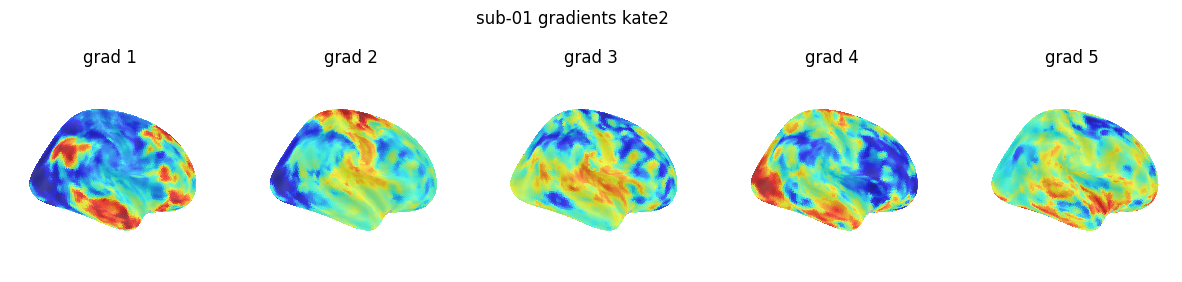

In [11]:
plot_grads(grad, sub, spec, confspec)

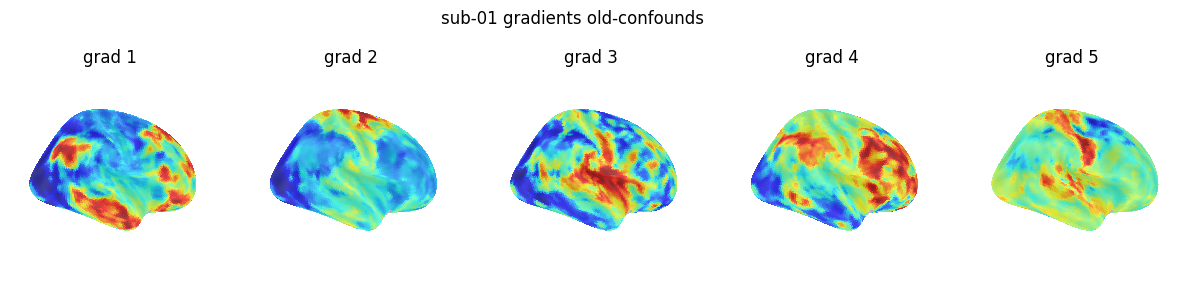

In [44]:
# old gradient
confspec = 'old-confounds'
spec = 'gradients' # 'g-aligned'
grad = np.load(op.join(bids_folder_base, 'derivatives', 'gradients', f'sub-{sub}' , f'sub-{sub}_{spec}_space-fsaverag5_n10.npy')) 

plot_grads(grad, sub, spec, confspec)